### 1.4.6.6. Dirac Delta and Transfer Functions

$$
\mathcal{L}\{\delta(t - t_0)\} = e^{-s t_0},
\qquad
Y(s) = W(s)\,G(s), \quad W(s) = \frac{1}{P(s)} \ (\text{transfer function}) .
$$

**Explanation:**

The **Dirac delta** $\delta(t - t_0)$ models a unit impulse — an idealized force concentrated at an instant — with transform $\mathcal{L}\{\delta(t-t_0)\} = e^{-st_0}$ (and $\mathcal{L}\{\delta(t)\} = 1$). For a linear equation $P(\tfrac{d}{dt})\,y = g$, transforming with zero initial conditions gives $Y(s) = W(s)G(s)$, where $W(s) = 1/P(s)$ is the **transfer function** — the system's input–output gain in the $s$-domain. Its inverse $h(t) = \mathcal{L}^{-1}\{W(s)\}$ is the **impulse response** (the output when $g = \delta$), and by the [convolution theorem](./05_convolution_theorem.ipynb) the response to any input is $y = h * g$. This transfer-function / impulse-response language is the foundation of [linear control design](../../../04_Optimal_Control) and the [LRC](../05_Modeling_with_Higher_Order_Equations/03_lrc_series_circuits.ipynb) and spring/mass plants.

**Properties:**
- The impulse response $h(t) = \mathcal{L}^{-1}\{W(s)\}$ characterizes the system completely.
- Output to a general input: $y(t) = (h * g)(t)$, the convolution of impulse response with input.

**Numerical Example:**

Strike an undamped oscillator with a unit impulse: $x'' + 4x = \delta(t)$, $x(0) = 0$, $x'(0) = 0$ (so $\omega = 2$).

**Transform** (zero initial conditions, $\mathcal{L}\{\delta(t)\} = 1$):

$$
s^2 X + 4X = 1 \;\Longrightarrow\; X(s) = \frac{1}{s^2 + 4} .
$$

The **transfer function** is $W(s) = \dfrac{1}{s^2 + 4}$ (here $X = W\cdot 1$ since the input transform is $1$).

**Invert** to get the **impulse response**:

$$
x(t) = h(t) = \mathcal{L}^{-1}\!\left\{\frac{1}{s^2+4}\right\} = \frac{1}{2}\sin 2t .
$$

The impulse "kicks" the oscillator into a sustained sinusoid of amplitude $\tfrac12$ — and the response to any forcing $g(t)$ is the convolution $h * g$.

In [1]:
import sympy as sp

t, s = sp.symbols("t s", positive=True)
X = sp.Symbol("X")

transformed = s**2 * X + 4 * X - 1
transfer_function = 1 / (s**2 + 4)
X_solution = sp.solve(transformed, X)[0]
impulse_response = sp.inverse_laplace_transform(X_solution, s, t)

print("transfer function W(s) =", transfer_function)
print("X(s) = W(s)*1          =", X_solution)
print("impulse response h(t)  =", impulse_response)

transfer function W(s) = 1/(s**2 + 4)
X(s) = W(s)*1          = 1/(s**2 + 4)
impulse response h(t)  = sin(2*t)/2


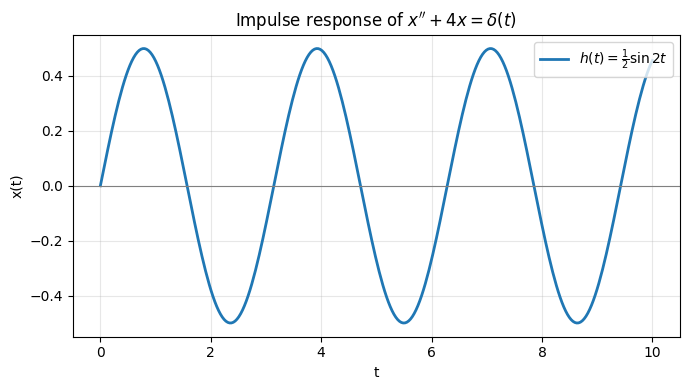

In [2]:
import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0, 10, 300)
response = 0.5 * np.sin(2 * time)

plt.figure(figsize=(7, 4))
plt.plot(time, response, linewidth=2, label=r"$h(t) = \frac{1}{2}\sin 2t$")
plt.axhline(0, color="gray", linewidth=0.8)
plt.xlabel("t"); plt.ylabel("x(t)"); plt.title(r"Impulse response of $x'' + 4x = \delta(t)$")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Convolution Theorem](./05_convolution_theorem.ipynb) | [Next: Power Series Solutions About Ordinary Points ➡️](../07_Series_Solutions/01_power_series_solutions_about_ordinary_points.ipynb)